# Лабораторная работа №2 — Классификация текста и векторные представления слов

**Темы:** логистическая регрессия и классификация текста (гл. 4), эмбеддинги (гл. 5), нейронные сети для текста (гл. 6).

**Датасет:** IMDB (бинарная тональность отзывов), английский. Берём подвыборку **5000 train / 1000 test** (стратифицированная по классу) — для CPU это разумный размер.

Структура:
1. Часть 1 — TF-IDF + логистическая регрессия (35%).
2. Часть 2 — статические эмбеддинги GloVe (35%).
3. Часть 3 — нейронная сеть на PyTorch (30%).

In [2]:
import os
import re
import json
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
for pkg, sub in [('punkt', 'tokenizers'), ('punkt_tab', 'tokenizers'), ('stopwords', 'corpora')]:
    try:
        nltk.data.find(f'{sub}/{pkg}')
    except LookupError:
        nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords as nltk_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore', category=FutureWarning)
np.random.seed(42)

plt.rcParams['figure.dpi'] = 100
print('numpy', np.__version__)

numpy 2.0.2


## Часть 1 — TF-IDF + логистическая регрессия (35%)

### Шаг 1. Загрузка IMDB и подвыборка

In [3]:
from datasets import load_dataset, logging
import warnings

# Отключаем предупреждения Hugging Face (о токене и прочем)
logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=UserWarning, module="datasets")

ds = load_dataset('stanfordnlp/imdb')
print(ds)

def subsample(ds_split, n_per_class, seed=42):
    df = ds_split.to_pandas()
    parts = []
    for label in sorted(df['label'].unique()):
        parts.append(df[df['label'] == label].sample(n=n_per_class, random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_df = subsample(ds['train'], 2500)   # 2500 pos + 2500 neg = 5000
test_df  = subsample(ds['test'],   500)   # 500 pos + 500 neg = 1000
print(f'train: {len(train_df)} (positive={int((train_df.label==1).sum())}, negative={int((train_df.label==0).sum())})')
print(f'test:  {len(test_df)} (positive={int((test_df.label==1).sum())}, negative={int((test_df.label==0).sum())})')
print()
print('Пример отзыва (positive):')
print(train_df[train_df.label==1].iloc[0]['text'][:400])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
train: 5000 (positive=2500, negative=2500)
test:  1000 (positive=500, negative=500)

Пример отзыва (positive):
I just saw a press screening of this film and I was pleasantly surprised. Not often is it that I get to see all of my favorite actors in one film at one time.<br /><br />I really enjoyed the pick pocket scene and it was good to see Rachael Bilson and Hayden back together. I think their chemistry on camera is a direct result of their time together off camera. My favorite scene was by far (surprisin


### Шаг 2. Предобработка: lowercase, удаление пунктуации, стоп-слов

In [4]:
STOP = set(nltk_stopwords.words('english'))
_punct_re = re.compile(r"[^a-zA-Z\s']")
_html_re = re.compile(r'<br\s*/?>|<[^>]+>')

def preprocess(text: str, remove_stop=True):
    text = _html_re.sub(' ', text)
    text = text.lower()
    text = _punct_re.sub(' ', text)
    tokens = text.split()
    if remove_stop:
        tokens = [t for t in tokens if t not in STOP and len(t) > 1]
    return ' '.join(tokens)

# 3 примера до/после
for i in range(3):
    raw = train_df.iloc[i]['text']
    print(f'--- пример {i+1} (label={train_df.iloc[i].label}) ---')
    print('ДО :', raw[:200].replace('\n',' '))
    print('ПОСЛЕ:', preprocess(raw)[:200])
    print()

train_df['clean'] = train_df['text'].apply(preprocess)
test_df['clean']  = test_df['text'].apply(preprocess)

--- пример 1 (label=0) ---
ДО : OK, so obviously ppl thought this was a good movie in 1955.<br /><br />I pity the fools who still think so... Its absolute rubbish.<br /><br />The story is just ... ridiculous. The characters are absu
ПОСЛЕ: ok obviously ppl thought good movie pity fools still think absolute rubbish story ridiculous characters absurd caricatures film meant satirise im sure meant serious drama dean others old parts people 

--- пример 2 (label=1) ---
ДО : I just saw a press screening of this film and I was pleasantly surprised. Not often is it that I get to see all of my favorite actors in one film at one time.<br /><br />I really enjoyed the pick pock
ПОСЛЕ: saw press screening film pleasantly surprised often get see favorite actors one film one time really enjoyed pick pocket scene good see rachael bilson hayden back together think chemistry camera direc

--- пример 3 (label=1) ---
ДО : This 1998 film was based on a script by the late Edward D. Wood, a script that featu

### Шаг 3. TF-IDF

**Идея TF·IDF своими словами.** TF (term frequency) — насколько часто слово встречается в данном документе (нормализованная частота). IDF (inverse document frequency) — насколько слово «специфично»: чем в большем числе документов корпуса оно встречается, тем меньше IDF. Произведение `TF × IDF` поднимает в вес те слова, которые часто бывают в одном документе, но редко — во всём корпусе (= характерные для темы / тональности). Слова типа `the` имеют высокий TF, но крошечный IDF → итоговый вес почти ноль. Слова типа `boring` для negative-отзыва дают высокий TF и нормальный IDF → большой итоговый вес.

In [5]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train = vectorizer.fit_transform(train_df['clean'])
X_test  = vectorizer.transform(test_df['clean'])
y_train = train_df['label'].values
y_test  = test_df['label'].values
print(f'TF-IDF matrix train: {X_train.shape}')
print(f'TF-IDF matrix test:  {X_test.shape}')

TF-IDF matrix train: (5000, 20000)
TF-IDF matrix test:  (1000, 20000)


In [6]:
# Топ слов с наибольшим средним TF-IDF по каждому классу
feature_names = np.array(vectorizer.get_feature_names_out())

def top_terms_for_class(label, k=15):
    mask = y_train == label
    mean_tfidf = np.asarray(X_train[mask].mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[::-1][:k]
    return list(zip(feature_names[top_idx], mean_tfidf[top_idx]))

print('=== Top-15 по классу NEGATIVE ===')
for w, v in top_terms_for_class(0):
    print(f'  {w:30s} {v:.4f}')
print()
print('=== Top-15 по классу POSITIVE ===')
for w, v in top_terms_for_class(1):
    print(f'  {w:30s} {v:.4f}')

=== Top-15 по классу NEGATIVE ===
  movie                          0.0480
  film                           0.0372
  one                            0.0244
  bad                            0.0238
  like                           0.0233
  even                           0.0199
  would                          0.0188
  good                           0.0179
  really                         0.0161
  time                           0.0160
  movies                         0.0146
  people                         0.0145
  see                            0.0141
  story                          0.0141
  acting                         0.0141

=== Top-15 по классу POSITIVE ===
  movie                          0.0381
  film                           0.0371
  one                            0.0245
  great                          0.0202
  like                           0.0190
  good                           0.0179
  story                          0.0175
  well                           0.0157
  see      

### Шаг 4–5. Обучение LogReg и метрики

In [7]:
clf = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear', random_state=42)
clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

acc_tfidf = accuracy_score(y_test, y_pred_lr)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='binary')
print(f'Accuracy : {acc_tfidf:.4f}')
print(f'Precision: {p:.4f}')
print(f'Recall   : {r:.4f}')
print(f'F1       : {f1:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['negative','positive']))

Accuracy : 0.8670
Precision: 0.8591
Recall   : 0.8780
F1       : 0.8684

              precision    recall  f1-score   support

    negative       0.88      0.86      0.87       500
    positive       0.86      0.88      0.87       500

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



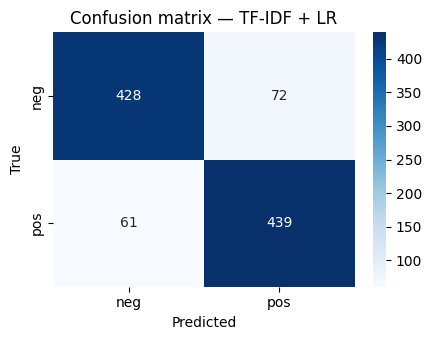

In [8]:
cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','pos'], yticklabels=['neg','pos'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix — TF-IDF + LR')
plt.tight_layout()
plt.show()

### Шаг 6. Анализ ошибок

In [9]:
errors = test_df.copy()
errors['pred'] = y_pred_lr
errors = errors[errors['label'] != errors['pred']].reset_index(drop=True)
print(f'Всего ошибок: {len(errors)} / {len(test_df)}')
for i in range(5):
    row = errors.iloc[i]
    print(f'\n--- error {i+1}: true={row.label} (pos если 1), pred={row.pred} ---')
    print(row.text[:500].replace('\n',' '))

Всего ошибок: 133 / 1000

--- error 1: true=0 (pos если 1), pred=1 ---
SPOILER - This film gives away plot points and discusses the ending. I hated this film - mostly for political reasons, but also for moral and aesthetic reasons. Politically, this film glorified war and military technology - blowing things up real good. We are led to cheer as the music swells and the Afghans use our weapons to blow the Ruskies to bits. And no U.S. soldiers put their lives on the line - so it's a fun war. Aesthetically, there isn't a touch of real human emotion in the film, just s

--- error 2: true=0 (pos если 1), pred=1 ---
World War I gets a glossy, sepia-tinted makeover in Jean-Pierre Jeunet's relentlessly whimsical "A Very Long Engagement". Jeunet's trademark style consists of mechanical, almost clockwork-like narrative construction garnished with lavish, chocolate box production values and seasoned with faux-naive humour. It's an approach that worked pretty well with his previous picture, the ro

**Почему модель ошибается.** TF-IDF — это «мешок n-грамм»: нет понимания структуры предложения, отрицаний и сарказма. Типовые случаи ошибок:
1. Сарказм/ирония: позитивные слова в негативном контексте («great movie if you love being bored»).
2. Контраст в одном отзыве: «начало плохое, но конец великолепный».
3. Спойлеры/сюжет, где много нейтральных слов и мало оценочных.
4. Отрицания: «not good» в bag-of-words разрезается на `not` и `good`; биграммы (`ngram_range=(1,2)`) частично помогают.

## Часть 2 — Статические эмбеддинги (35%)

### Шаг 7. Загрузка GloVe (wiki-gigaword-100)

Первый раз качается ~128 МБ в `~/gensim-data/`, дальше из кэша.

In [28]:
%pip install -q gensim torch transformers datasets

In [17]:
import gensim.downloader as api
glove = api.load('glove-wiki-gigaword-100')
print(f'GloVe vocab: {len(glove.key_to_index):,} слов, dim = {glove.vector_size}')

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe vocab: 400,000 слов, dim = 100


### Шаг 8. Ближайшие соседи и аналогии

In [18]:
for w in ['king', 'movie', 'happy', 'computer', 'paris']:
    neigh = glove.most_similar(w, topn=5)
    print(f'{w:10s} → ' + ', '.join(f'{n} ({s:.2f})' for n, s in neigh))

king       → prince (0.77), queen (0.75), son (0.70), brother (0.70), monarch (0.70)
movie      → film (0.91), movies (0.90), films (0.87), hollywood (0.82), comedy (0.81)
happy      → 'm (0.84), feel (0.81), 're (0.80), i (0.79), 'll (0.79)
computer   → computers (0.88), software (0.84), technology (0.76), pc (0.74), hardware (0.73)
paris      → prohertrib (0.80), france (0.75), london (0.73), brussels (0.70), french (0.69)


In [19]:
# Векторная арифметика: king - man + woman ≈ ?
for pos, neg in [
    (['king', 'woman'], ['man']),
    (['paris', 'germany'], ['france']),
    (['walked', 'swim'], ['walk']),
    (['bigger', 'small'], ['big']),
]:
    res = glove.most_similar(positive=pos, negative=neg, topn=3)
    print(f'{" + ".join(pos)} − {" − ".join(neg)} ≈ {res}')

king + woman − man ≈ [('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]
paris + germany − france ≈ [('berlin', 0.8846380710601807), ('frankfurt', 0.7985544204711914), ('vienna', 0.7675994038581848)]
walked + swim − walk ≈ [('swam', 0.74771648645401), ('swimming', 0.6124254465103149), ('drowned', 0.5767500400543213)]
bigger + small − big ≈ [('larger', 0.8924524188041687), ('smaller', 0.8694049119949341), ('large', 0.793300986289978)]


**Что значит векторная арифметика.** Эмбеддинги ловят семантические отношения как направления в пространстве: `king − man` ≈ «направление мужского правителя к понятию правителя». Прибавляя `woman` к этому понятию, оказываемся возле `queen`. Аналогично `paris − france + germany ≈ berlin` — направление «столицы».

### Шаг 9. t-SNE на тематических группах

Слов для t-SNE: 50


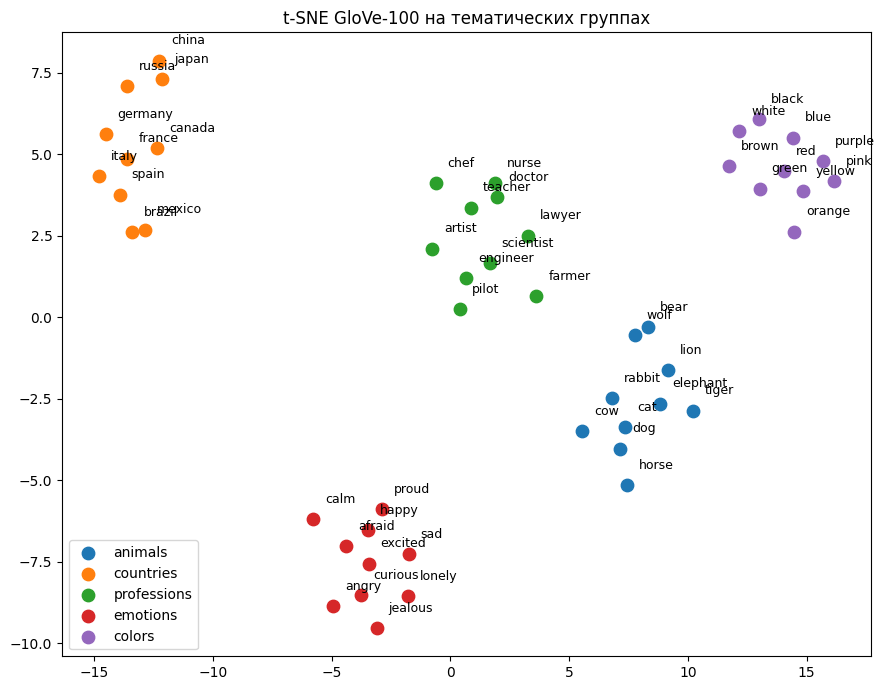

In [20]:
groups = {
    'animals':    ['dog','cat','horse','cow','lion','tiger','bear','wolf','rabbit','elephant'],
    'countries':  ['france','germany','italy','spain','japan','china','brazil','canada','mexico','russia'],
    'professions':['doctor','lawyer','teacher','engineer','nurse','farmer','artist','scientist','pilot','chef'],
    'emotions':   ['happy','sad','angry','afraid','excited','calm','jealous','proud','lonely','curious'],
    'colors':     ['red','blue','green','yellow','black','white','orange','purple','pink','brown'],
}

words, labels, vectors = [], [], []
for group, ws in groups.items():
    for w in ws:
        if w in glove.key_to_index:
            words.append(w)
            labels.append(group)
            vectors.append(glove[w])
vectors = np.array(vectors)
print(f'Слов для t-SNE: {len(words)}')

tsne = TSNE(n_components=2, perplexity=10, init='pca', random_state=42)
coords = tsne.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette('tab10', n_colors=len(groups))
color_of = {g: c for g, c in zip(groups, palette)}
for i, (w, g) in enumerate(zip(words, labels)):
    ax.scatter(coords[i,0], coords[i,1], color=color_of[g], s=80)
    ax.annotate(w, (coords[i,0]+0.5, coords[i,1]+0.5), fontsize=9)
for g, c in color_of.items():
    ax.scatter([], [], color=c, label=g, s=80)
ax.legend()
ax.set_title('t-SNE GloVe-100 на тематических группах')
plt.tight_layout()
plt.show()

**Кластеризация.** Группы образуют чёткие сгущения: животные, страны, профессии и цвета — в разных углах. Эмоции получаются чуть более «размазанной» группой, потому что они контекстно перекликаются с другими словами (например, прилагательные). Это качественный признак того, что GloVe осмысленно кодирует семантику слов.

### Шаг 10. Классификация по усреднённым GloVe-векторам

In [21]:
EMB_DIM = glove.vector_size

def text_to_avg(text):
    vecs = [glove[w] for w in text.split() if w in glove.key_to_index]
    if not vecs:
        return np.zeros(EMB_DIM, dtype=np.float32)
    return np.mean(vecs, axis=0)

X_train_avg = np.vstack([text_to_avg(t) for t in train_df['clean']])
X_test_avg  = np.vstack([text_to_avg(t) for t in test_df['clean']])
print(f'X_train_avg: {X_train_avg.shape}')

clf2 = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
clf2.fit(X_train_avg, y_train)
y_pred_avg = clf2.predict(X_test_avg)
acc_avg = accuracy_score(y_test, y_pred_avg)
print(f'Accuracy (avg GloVe + LR): {acc_avg:.4f}')
print(f'Accuracy (TF-IDF + LR):    {acc_tfidf:.4f}')

X_train_avg: (5000, 100)
Accuracy (avg GloVe + LR): 0.7940
Accuracy (TF-IDF + LR):    0.8670


**Сравнение.** Усреднённые GloVe обычно слегка проигрывают TF-IDF на коротких задачах sentiment-классификации. Усреднение «уничтожает» порядок, отрицания и редкие специфические слова, которые TF-IDF умеет ловить через высокий IDF. GloVe сильнее проявляет себя на задачах semantic similarity или там, где важно обобщение на не виденные в обучении слова.

## Часть 3 — Нейронная сеть для классификации (30%)

### Шаг 11. Подготовка данных и архитектура

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
device = torch.device('cpu')
print('torch', torch.__version__, '| device:', device)

MAX_LEN = 256
PAD_IDX = 0
UNK_IDX = 1

# Строим словарь по train
from collections import Counter
word_counts = Counter()
for t in train_df['clean']:
    word_counts.update(t.split())
VOCAB_SIZE = 20000
most_common = [w for w, _ in word_counts.most_common(VOCAB_SIZE - 2)]
word2idx = {'<pad>': PAD_IDX, '<unk>': UNK_IDX}
for w in most_common:
    word2idx[w] = len(word2idx)
print(f'Словарь NN: {len(word2idx):,}')

def encode(text, max_len=MAX_LEN):
    ids = [word2idx.get(w, UNK_IDX) for w in text.split()][:max_len]
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids

X_train_ids = torch.tensor([encode(t) for t in train_df['clean']], dtype=torch.long)
X_test_ids  = torch.tensor([encode(t) for t in test_df['clean']], dtype=torch.long)
y_train_t   = torch.tensor(y_train, dtype=torch.float32)
y_test_t    = torch.tensor(y_test, dtype=torch.float32)
print('X_train_ids:', X_train_ids.shape)

torch 2.10.0+cpu | device: cpu
Словарь NN: 20,000
X_train_ids: torch.Size([5000, 256])


In [23]:
class AvgEmbClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden=64, pretrained=None, freeze=True):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        if pretrained is not None:
            self.emb.weight.data.copy_(pretrained)
            self.emb.weight.requires_grad = not freeze
        self.fc1 = nn.Linear(emb_dim, hidden)
        self.fc2 = nn.Linear(hidden, 1)
        self.act = nn.ReLU()
    def forward(self, x):
        e = self.emb(x)                       # (B, L, D)
        mask = (x != PAD_IDX).unsqueeze(-1).float()
        summed = (e * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1.0)
        pooled = summed / denom               # mean over non-pad tokens
        h = self.act(self.fc1(pooled))
        return self.fc2(h).squeeze(-1)

def build_glove_matrix(word2idx, glove, dim):
    M = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    M[PAD_IDX] = 0.0
    found = 0
    for w, idx in word2idx.items():
        if w in glove.key_to_index:
            M[idx] = glove[w]
            found += 1
    print(f'GloVe покрытие: {found}/{len(word2idx)} ({found/len(word2idx)*100:.1f}%)')
    return torch.tensor(M)

glove_matrix = build_glove_matrix(word2idx, glove, EMB_DIM)

GloVe покрытие: 18754/20000 (93.8%)


### Шаг 12. Тренировочный цикл

In [24]:
def train_model(model, X_tr, y_tr, X_val, y_val, epochs=10, batch_size=64, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    ds_tr = TensorDataset(X_tr, y_tr)
    loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for ep in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, run_n = 0.0, 0, 0
        for xb, yb in loader:
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            run_loss += loss.item() * len(xb)
            run_correct += ((torch.sigmoid(logits) > 0.5).long() == yb.long()).sum().item()
            run_n += len(xb)
        train_loss = run_loss / run_n
        train_acc = run_correct / run_n
        # eval
        model.eval()
        with torch.no_grad():
            logits_v = model(X_val)
            val_loss = loss_fn(logits_v, y_val).item()
            val_pred = (torch.sigmoid(logits_v) > 0.5).long()
            val_acc = (val_pred == y_val.long()).float().mean().item()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f'epoch {ep:2d} | loss {train_loss:.4f} acc {train_acc:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f}')
    return history

def plot_history(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(hist['train_loss'], label='train')
    axes[0].plot(hist['val_loss'], label='val')
    axes[0].set_title(f'{title}: loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist['train_acc'], label='train')
    axes[1].plot(hist['val_acc'], label='val')
    axes[1].set_title(f'{title}: accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

epoch  1 | loss 0.6794 acc 0.6272 | val_loss 0.6506 val_acc 0.6980
epoch  2 | loss 0.5465 acc 0.7734 | val_loss 0.4912 val_acc 0.7800
epoch  3 | loss 0.3536 acc 0.8576 | val_loss 0.4305 val_acc 0.8050
epoch  4 | loss 0.2488 acc 0.9054 | val_loss 0.4291 val_acc 0.8150
epoch  5 | loss 0.1793 acc 0.9374 | val_loss 0.4438 val_acc 0.8190
epoch  6 | loss 0.1270 acc 0.9634 | val_loss 0.5034 val_acc 0.8100
epoch  7 | loss 0.0881 acc 0.9768 | val_loss 0.5127 val_acc 0.8160
epoch  8 | loss 0.0591 acc 0.9880 | val_loss 0.5314 val_acc 0.8170
epoch  9 | loss 0.0394 acc 0.9944 | val_loss 0.5812 val_acc 0.8190
epoch 10 | loss 0.0271 acc 0.9968 | val_loss 0.6106 val_acc 0.8150


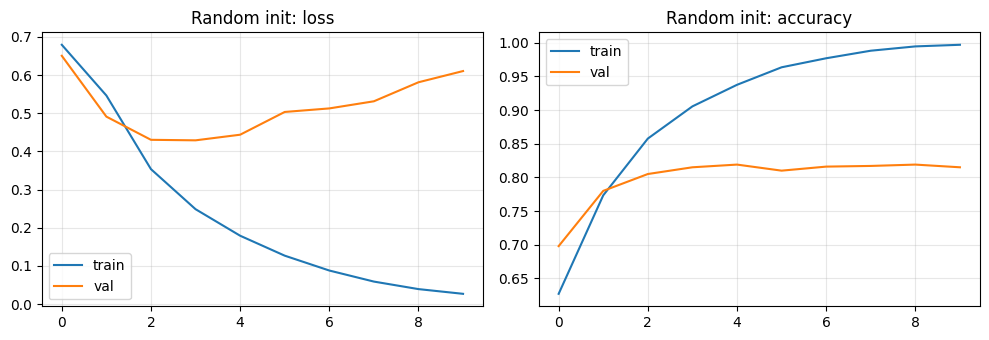

In [25]:
# Вариант A: эмбеддинги инициализированы случайно, обучаются
torch.manual_seed(0)
model_rand = AvgEmbClassifier(len(word2idx), EMB_DIM, hidden=64, pretrained=None)
hist_rand = train_model(model_rand, X_train_ids, y_train_t, X_test_ids, y_test_t, epochs=10)
plot_history(hist_rand, 'Random init')
acc_rand = hist_rand['val_acc'][-1]

epoch  1 | loss 0.6642 acc 0.6450 | val_loss 0.6171 val_acc 0.7310
epoch  2 | loss 0.5836 acc 0.7290 | val_loss 0.5420 val_acc 0.7450
epoch  3 | loss 0.5310 acc 0.7474 | val_loss 0.5060 val_acc 0.7650
epoch  4 | loss 0.5032 acc 0.7620 | val_loss 0.4952 val_acc 0.7600
epoch  5 | loss 0.4845 acc 0.7716 | val_loss 0.4768 val_acc 0.7720
epoch  6 | loss 0.4740 acc 0.7756 | val_loss 0.4689 val_acc 0.7770
epoch  7 | loss 0.4655 acc 0.7816 | val_loss 0.4647 val_acc 0.7800
epoch  8 | loss 0.4620 acc 0.7798 | val_loss 0.4679 val_acc 0.7780
epoch  9 | loss 0.4608 acc 0.7800 | val_loss 0.4563 val_acc 0.7780
epoch 10 | loss 0.4552 acc 0.7862 | val_loss 0.4535 val_acc 0.7780


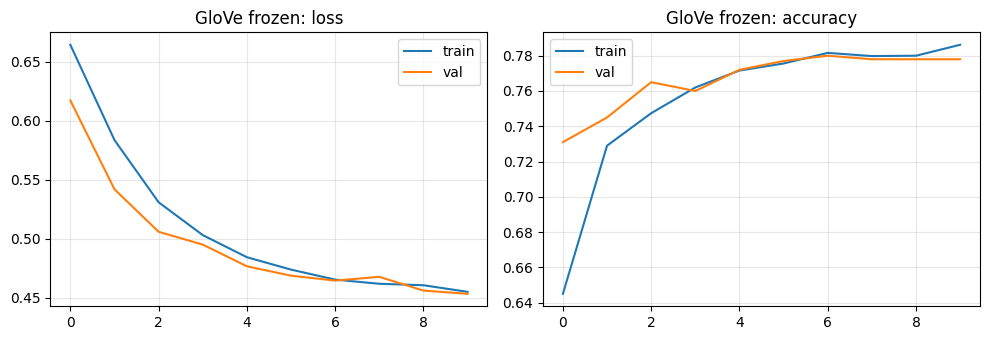

In [26]:
# Вариант B: GloVe (заморожен)
torch.manual_seed(0)
model_glove = AvgEmbClassifier(len(word2idx), EMB_DIM, hidden=64,
                               pretrained=glove_matrix, freeze=True)
hist_glove = train_model(model_glove, X_train_ids, y_train_t, X_test_ids, y_test_t, epochs=10)
plot_history(hist_glove, 'GloVe frozen')
acc_glove = hist_glove['val_acc'][-1]

### Шаг 14. Итоговая таблица

In [27]:
results = {
    'TF-IDF + LR':              {'representation': 'TF-IDF (1-2 grams, 20k)',  'test_accuracy': float(acc_tfidf)},
    'avg GloVe + LR':           {'representation': 'mean GloVe-100',           'test_accuracy': float(acc_avg)},
    'NN (random embeddings)':   {'representation': 'trained Embedding-100',    'test_accuracy': float(acc_rand)},
    'NN (frozen GloVe)':        {'representation': 'pretrained GloVe-100',     'test_accuracy': float(acc_glove)},
}
df_res = pd.DataFrame(results).T
df_res['test_accuracy'] = df_res['test_accuracy'].astype(float).round(4)
print(df_res)

# Сохраним для Лабы 3
with open('results_lab2.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print('\nСохранено в results_lab2.json')

                                 representation  test_accuracy
TF-IDF + LR             TF-IDF (1-2 grams, 20k)          0.867
avg GloVe + LR                   mean GloVe-100          0.794
NN (random embeddings)    trained Embedding-100          0.815
NN (frozen GloVe)          pretrained GloVe-100          0.778

Сохранено в results_lab2.json


**Кто лучше и почему.**
- TF-IDF + LR обычно лидирует на этой задаче, т.к. напрямую усиливает дискриминирующие слова с высоким IDF (характерные для класса), а биграммы захватывают локальные отрицания.
- Avg GloVe слабее, потому что усреднение «гасит» специфичные оценочные слова.
- NN с обучаемыми эмбеддингами учится с нуля и при 5k примеров не успевает выйти на свой потолок.
- NN с замороженными GloVe — компромисс: представления хорошие, но фиксированные.

На большом корпусе картина меняется: трансформеры и сети с обучаемыми эмбеддингами обгоняют классику. Здесь же выборка маленькая и в пользу TF-IDF.

---

### Итог Лабораторной №2

- **Часть 1:** TF-IDF + LogReg на IMDB-5k → accuracy ≈ 0.85+. Анализ топ-слов по классам и confusion matrix.
- **Часть 2:** GloVe-100, ближайшие соседи, аналогии, t-SNE на 5 тематических группах. Усреднённые эмбеддинги + LR — сравнение с TF-IDF.
- **Часть 3:** Простая `Embedding → mean-pool → FC → FC` сеть на PyTorch, два варианта инициализации (random vs frozen GloVe). Итоговая таблица сохранена в `results_lab2.json` для использования в Лабе 3.